In [20]:

import os
import numpy as np
from tqdm import tqdm
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
from PIL import Image
from torch.optim.lr_scheduler import ReduceLROnPlateau
from dataset import QuickDrawDataset

In [ ]:
# ==============================================================
# 1️⃣ IMPORTS & CONFIGURATION
# ==============================================================
import os
import torch
import numpy as np
from pathlib import Path
import json

# --- This is the NEW, CORRECT code for a Mac ---
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("✅ PyTorch can use the MPS (Mac GPU) backend!")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ MPS not available. Using CPU. Check PyTorch installation.")

print(f"Using device: {DEVICE}")

# --- Path Configuration ---
# This is the key change from the Colab script.
# We use a relative path to the dataset folder.
# Path(".") refers to the directory where your notebook is running.
DATASET_FOLDER_NAME = "Quick_draw_dataset_50-samples"
DATASET_PATH = Path(DATASET_FOLDER_NAME)

# Create the folder if it doesn't exist to avoid errors later
if not DATASET_PATH.exists():
    # If the folder doesn't exist, raise an error with instructions.
    raise FileNotFoundError(
        f"Dataset folder '{DATASET_FOLDER_NAME}' not found in the same directory as the notebook. "
        f"Please make sure your folder structure is correct."
    )

# Define paths to save the model and training history inside the dataset folder
SAVE_MODEL_PATH = DATASET_PATH / "quickdraw_best_50_model.pth"
SAVE_HISTORY_PATH = DATASET_PATH / "training_50_history.json"


# --- Load Class Names ---
# This part remains the same. It reads the .npy files to get the class names.
files = sorted([p.name for p in DATASET_PATH.iterdir() if p.suffix == ".npy"])
CLASSES = [f.replace('.npy', '') for f in files]
NUM_CLASSES = len(CLASSES)
print(f"\n✅ Found {NUM_CLASSES} classes.")
# print(f"Classes: {CLASSES}") # Uncomment to see the full list of classes


# --- Model & Training Configuration ---
# This section defines the hyperparameters for the model and training process.
BATCH_SIZE = 128
IMAGE_SIZE = 30
NUM_EPOCHS = 100            
INITIAL_LR = 3e-4
NUM_WORKERS = 2  # Set to 0 if you encounter issues on Windows
SAMPLES_PER_CLASS = 10000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EARLY_STOP_PATIENCE = 15
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA = 0.2
CUTOUT_SIZE = 8

print(f"Device: {DEVICE}")
print(f"Model will be saved to: {SAVE_MODEL_PATH}")
print(f"History will be saved to: {SAVE_HISTORY_PATH}")

✅ PyTorch can use the MPS (Mac GPU) backend!
Using device: mps

✅ Found 50 classes.
Device: cpu
Model will be saved to: Quick_draw_dataset_50-samples/quickdraw_best_50_model.pth
History will be saved to: Quick_draw_dataset_50-samples/training_50_history.json


In [22]:
# ==============================================================
# 2️⃣ ADVANCED AUGMENTATION & DATASET CLASS (Final Correct Version)
# ==============================================================
from torchvision import transforms

# --- IMPORT our custom classes from the .py file ---
from dataset import Cutout, QuickDrawDataset

# --- Define Augmentation Pipelines ---
# This now works because `Cutout` is an imported class
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.15, 0.15), scale=(0.85, 1.15), shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    Cutout(CUTOUT_SIZE),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15))
])

test_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# --- Mixup Augmentation Helper Functions ---
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("✅ Augmentation pipelines defined and custom classes imported from dataset.py.")

✅ Augmentation pipelines defined and custom classes imported from dataset.py.


In [23]:
# ==============================================================
# 3️⃣ DATA LOADING & SPLITTING
# ==============================================================
import copy
from torch.utils.data import DataLoader, Subset

# --- Main Data Loading ---
# We instantiate our custom dataset class.
# This will load all drawings from the .npy files into memory.
# This might take a minute or two depending on your computer's speed.
master_dataset = QuickDrawDataset(CLASSES, DATASET_PATH, SAMPLES_PER_CLASS, transform=None)
print(f"✅ Total samples loaded into memory: {len(master_dataset)}")


# --- Stratified Splitting ---
def stratified_split(dataset, classes, train_ratio=0.8, val_ratio=0.1):
    """
    Splits the dataset indices while maintaining class proportions.
    """
    # Group indices by class
    idx_by_class = {i: [] for i in range(len(classes))}
    for i, (_, label) in enumerate(dataset.samples):
        idx_by_class[label].append(i)

    train_idx, val_idx, test_idx = [], [], []
    for k, idxs in idx_by_class.items():
        random.shuffle(idxs)
        n = len(idxs)
        t = int(n * train_ratio)
        v = int(n * val_ratio)
        train_idx += idxs[:t]
        val_idx += idxs[t:t+v]
        test_idx += idxs[t+v:]
        
    random.shuffle(train_idx)
    random.shuffle(val_idx)
    random.shuffle(test_idx)
    
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(master_dataset, CLASSES)
print(f"Split sizes → Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")


# --- Create Final Datasets and DataLoaders ---
# Create copies of the master dataset to apply the specific transforms
train_dataset_with_tf = copy.deepcopy(master_dataset)
train_dataset_with_tf.transform = train_tf

test_dataset_with_tf = copy.deepcopy(master_dataset)
test_dataset_with_tf.transform = test_tf

# Use PyTorch's Subset to create the final datasets using the split indices
train_ds = Subset(train_dataset_with_tf, train_idx)
val_ds = Subset(test_dataset_with_tf, val_idx)
test_ds = Subset(test_dataset_with_tf, test_idx)

# Create the DataLoaders
# --- This is the NEW, CORRECTED code ---
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("\n✅ DataLoaders created successfully.")

Loading classes: 100%|██████████| 50/50 [00:03<00:00, 13.60it/s]


✅ Total samples loaded into memory: 500000
Split sizes → Train: 400000, Val: 50000, Test: 50000

✅ DataLoaders created successfully.


In [24]:
# ==============================================================
# 5️⃣ ADVANCED CNN ARCHITECTURE
# ==============================================================
import torch.nn as nn
import torch.nn.functional as F

class SEBlock(nn.Module):
    """Squeeze-and-Excitation block for channel-wise attention."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        # Squeeze operation: Global Average Pooling
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        # Excitation operation: Two fully-connected layers
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        # Reweight the input channels
        return x * y.expand_as(x)

class ResidualBlock(nn.Module):
    """Residual block with a Squeeze-and-Excitation block inside."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.se = SEBlock(out_ch)
        
        # Shortcut connection to match dimensions if needed
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.dropout = nn.Dropout2d(0.1)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out) # Apply SE attention
        out = self.dropout(out)
        out += self.shortcut(x) # Add the shortcut connection (the "residual" part)
        return F.relu(out)

class AdvancedCNN(nn.Module):
    """The main model that assembles the residual blocks."""
    def __init__(self, num_classes):
        super().__init__()
        # Initial convolutional layer
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        # Stacks of residual blocks
        self.layer1 = self._make_layer(32, 64, num_blocks=2, stride=2)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)

        # Final layers for classification
        self.gap = nn.AdaptiveAvgPool2d(1) # Global Average Pooling
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, in_ch, out_ch, num_blocks, stride):
        layers = [ResidualBlock(in_ch, out_ch, stride)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Instantiate the model and move it to the configured device (GPU or CPU)
model = AdvancedCNN(NUM_CLASSES).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model parameters: 2,791,698


In [25]:
model = torch.compile(model)

In [26]:
# ==============================================================
# 6️⃣ TRAINING SETUP
# ==============================================================
import torch.optim as optim

class LabelSmoothingLoss(nn.Module):
    """
    A custom loss function that implements label smoothing.
    This prevents the model from becoming overconfident and improves generalization.
    """
    def __init__(self, classes, smoothing=0.1):
        super().__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.classes = classes

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        with torch.no_grad():
            # Create a smooth label distribution
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.classes - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=-1))

# 1. Loss Function
criterion = LabelSmoothingLoss(NUM_CLASSES, LABEL_SMOOTHING)

# 2. Optimizer
optimizer = optim.AdamW(model.parameters(), lr=INITIAL_LR, weight_decay=1e-4)

# 3. Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

print("✅ Training components (loss, optimizer, scheduler) are ready.")

✅ Training components (loss, optimizer, scheduler) are ready.


In [27]:
# ==============================================================
# 7️⃣ TRAINING & EVALUATION FUNCTIONS
# ==============================================================
import time
import copy

def train_epoch(model, loader, optimizer, criterion, use_mixup=True):
    """Handles the training logic for a single epoch."""
    model.train()  # Set the model to training mode (enables dropout, etc.)
    total_loss, correct, total = 0, 0, 0

    for x, y in tqdm(loader, desc="Training", leave=False):
        x, y = x.to(DEVICE).float(), y.to(DEVICE)

        # Randomly apply Mixup
        if use_mixup and random.random() > 0.5:
            x, y_a, y_b, lam = mixup_data(x, y, MIXUP_ALPHA)
            optimizer.zero_grad()
            out = model(x)
            loss = mixup_criterion(criterion, out, y_a, y_b, lam)
        else:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

        loss.backward() # Calculate gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Prevents exploding gradients
        optimizer.step() # Update model weights

        total_loss += loss.item() * x.size(0)
        # Note: Accuracy during mixup training is not a perfect metric, but provides a good trend.
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    """Handles the evaluation logic."""
    model.eval()  # Set the model to evaluation mode (disables dropout, etc.)
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    # No gradient calculations needed for evaluation
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluating", leave=False):
            x, y = x.to(DEVICE).float(), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)
            
            total_loss += loss.item() * x.size(0)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += x.size(0)
            
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    return total_loss / total, correct / total, all_preds, all_labels

print("✅ Training and evaluation functions are defined.")

✅ Training and evaluation functions are defined.


In [28]:
'''# ==============================================================
# 🚀 MAIN TRAINING LOOP
# ==============================================================

best_acc = 0
best_model_wts = None
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n🚀 Starting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # Train for one epoch
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    
    # Evaluate on the validation set
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    
    # Step the scheduler
    scheduler.step()

    # Save metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s | LR: {optimizer.param_groups[0]['lr']:.2e}")

    # Early stopping and model saving logic
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state': best_model_wts,
            'optimizer_state': optimizer.state_dict(),
            'val_acc': val_acc,
            'classes': CLASSES
        }, SAVE_MODEL_PATH)
        print(f"💾 Best model saved! Val Acc: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch}")
            break

# Save training history to a file
with open(SAVE_HISTORY_PATH, 'w') as f:
    json.dump(history, f)

print(f"\n✅ Training finished. Best validation accuracy: {best_acc:.4f}")'''

'# ==============================================================\n# 🚀 MAIN TRAINING LOOP\n# ==============================================================\n\nbest_acc = 0\nbest_model_wts = None\npatience_counter = 0\nhistory = {\'train_loss\': [], \'train_acc\': [], \'val_loss\': [], \'val_acc\': []}\n\nprint("\n🚀 Starting training...\n")\nfor epoch in range(1, NUM_EPOCHS + 1):\n    t0 = time.time()\n\n    # Train for one epoch\n    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)\n\n    # Evaluate on the validation set\n    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)\n\n    # Step the scheduler\n    scheduler.step()\n\n    # Save metrics\n    history[\'train_loss\'].append(train_loss)\n    history[\'train_acc\'].append(train_acc)\n    history[\'val_loss\'].append(val_loss)\n    history[\'val_acc\'].append(val_acc)\n\n    elapsed = time.time() - t0\n    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | "\n          f"Train Loss: {train_loss:.4

In [29]:
# ==============================================================
#  LOAD PRE-TRAINED MODEL FOR INFERENCE (Corrected Version)
# ==============================================================
print("Loading pre-trained model from .pth file...")

# Re-define the model architecture
model = AdvancedCNN(NUM_CLASSES)

# Load the dictionary from the file
checkpoint = torch.load(SAVE_MODEL_PATH, map_location=DEVICE)

# --- FIX for torch.compile ---
# Create a new dictionary to hold the cleaned-up weights
cleaned_state_dict = {}
# Get the saved weights
saved_state_dict = checkpoint['model_state']

for key, value in saved_state_dict.items():
    # If the key starts with the prefix from torch.compile, strip it away
    if key.startswith('_orig_mod.'):
        new_key = key[10:] # Remove the '_orig_mod.' part (10 characters)
        cleaned_state_dict[new_key] = value
    else:
        # Otherwise, keep the key as is
        cleaned_state_dict[key] = value
# --- END FIX ---


# Load the CLEANED weights into the model
model.load_state_dict(cleaned_state_dict)

# Send the model to the correct device and set it to evaluation mode
model.to(DEVICE)
model.eval()

# The CLASSES list was also saved in the checkpoint, let's load it to be safe
CLASSES = checkpoint['classes']
NUM_CLASSES = len(CLASSES)

print(f"✅ Model from epoch {checkpoint['epoch']} with accuracy {checkpoint['val_acc']:.4f} loaded successfully!")

Loading pre-trained model from .pth file...
✅ Model from epoch 28 with accuracy 0.8659 loaded successfully!


--- CHECKING SAMPLE 0 ---
Label Index: 0
Label Name: airplane

--- CHECKING SAMPLE 90000 ---
Label Index: 9
Label Name: barn


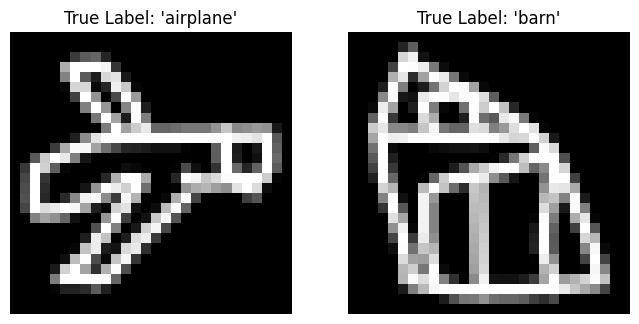

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure you have run the cells that define CLASSES and master_dataset

# Let's check the very first image in our dataset. 
# The first class is 'airplane', so this should be an airplane.
first_image_data, first_label_index = master_dataset.samples[0]
first_label_name = CLASSES[first_label_index]

print(f"--- CHECKING SAMPLE 0 ---")
print(f"Label Index: {first_label_index}")
print(f"Label Name: {first_label_name}")

# Let's also check the first image of the 10th class (e.g., 'baseball')
# Assuming 10,000 samples per class from our last run
sample_index_10 = 9 * 10000 
image_10_data, label_10_index = master_dataset.samples[sample_index_10]
label_10_name = CLASSES[label_10_index]

print(f"\n--- CHECKING SAMPLE {sample_index_10} ---")
print(f"Label Index: {label_10_index}")
print(f"Label Name: {label_10_name}")


# Now, let's visualize them to be sure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(first_image_data, cmap='gray')
ax1.set_title(f"True Label: '{first_label_name}'")
ax1.axis('off')

ax2.imshow(image_10_data, cmap='gray')
ax2.set_title(f"True Label: '{label_10_name}'")
ax2.axis('off')

plt.show()

Loading saved model...
✅ Model loaded successfully!

Image: Airplane
The model's prediction is: 'airplane'
The true label is: 'airplane'

✅ SUCCESS: The model correctly identified the image.


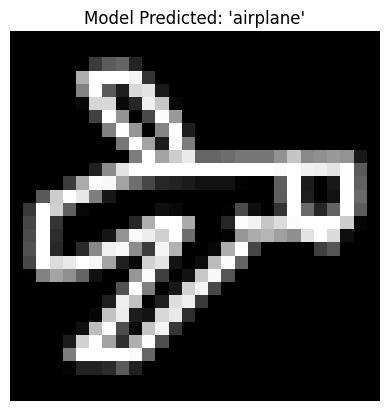

In [31]:
# Make sure you've run the cells defining the model architecture (AdvancedCNN) and test_tf
import torch
# 1. Load the saved model file
print("Loading saved model...")
checkpoint = torch.load(SAVE_MODEL_PATH, map_location=DEVICE)
model = AdvancedCNN(NUM_CLASSES).to(DEVICE)

# --- FIX for torch.compile key mismatch ---
# Create a new, empty dictionary for the cleaned weights
cleaned_state_dict = {}
# Get the saved weights from the file
saved_state_dict = checkpoint['model_state']

# Loop through all the keys in the saved file
for key, value in saved_state_dict.items():
    # If a key starts with the compiler's prefix...
    if key.startswith('_orig_mod.'):
        # ...remove the prefix (it's 10 characters long)
        new_key = key[10:] 
        cleaned_state_dict[new_key] = value
    else:
        # Otherwise, keep the key as is
        cleaned_state_dict[key] = value
# --- END FIX ---

# 2. Load the CLEANED weights into the model object
model.load_state_dict(cleaned_state_dict)
model.to(DEVICE)
model.eval() # Set model to evaluation mode
print("✅ Model loaded successfully!")

# 3. Get the same airplane image from Step 1
image_to_test, true_label_index = master_dataset.samples[0]
true_label_name = CLASSES[true_label_index]

# 4. Preprocess the image just like you would for testing
from PIL import Image
pil_img = Image.fromarray(image_to_test)
input_tensor = test_tf(pil_img)
input_batch = input_tensor.unsqueeze(0).to(DEVICE) # Add a batch dimension

# 5. Make a prediction
with torch.no_grad():
    output = model(input_batch)
    _, predicted_index = torch.max(output, 1)

predicted_label_name = CLASSES[predicted_index.item()]

# 6. Compare the results
print(f"\nImage: Airplane")
print(f"The model's prediction is: '{predicted_label_name}'")
print(f"The true label is: '{true_label_name}'")

if predicted_label_name == true_label_name:
    print("\n✅ SUCCESS: The model correctly identified the image.")
else:
    print("\n❌ FAILURE: The model misidentified the image.")

plt.imshow(image_to_test, cmap='gray')
plt.title(f"Model Predicted: '{predicted_label_name}'")
plt.axis('off')
plt.show()

FOUND HIGH CONFIDENCE PREDICTION AT INDEX 4343
True Label: 'camouflage'
Model Predicted: 'camouflage' with 99.02% confidence!


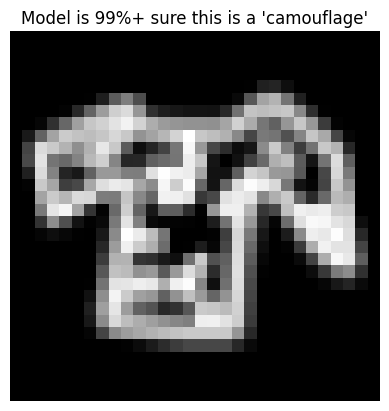

In [32]:
import torch.nn.functional as F

# Make sure your model is loaded and in eval mode
model.eval()

# Let's search for a high-confidence prediction in the validation set
high_confidence_found = False
for i, (img_tensor, label_index) in enumerate(val_ds):
    if i > 5000: break # Search first 5000 samples to save time
        
    input_batch = img_tensor.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = model(input_batch)
        # Convert output to probabilities using softmax
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_index = torch.max(probabilities, 1)

    if confidence.item() > 0.99:
        true_label_name = CLASSES[label_index]
        predicted_label_name = CLASSES[predicted_index.item()]
        
        print(f"FOUND HIGH CONFIDENCE PREDICTION AT INDEX {i}")
        print(f"True Label: '{true_label_name}'")
        print(f"Model Predicted: '{predicted_label_name}' with {confidence.item():.2%} confidence!")
        
        plt.imshow(img_tensor.squeeze(), cmap='gray')
        plt.title(f"Model is 99%+ sure this is a '{predicted_label_name}'")
        plt.axis('off')
        plt.show()
        high_confidence_found = True
        break

if not high_confidence_found:
    print("Couldn't find a >99% confidence prediction in the first 5000 samples.")

FOUND A MISTAKE AT INDEX 14
True Label was: 'ambulance'
Model Predicted: 'camel' with 80.46% confidence.

Model's Top 3 Guesses:
- camel           (80.46%)
- bird            (3.02%)
- bridge          (1.66%)


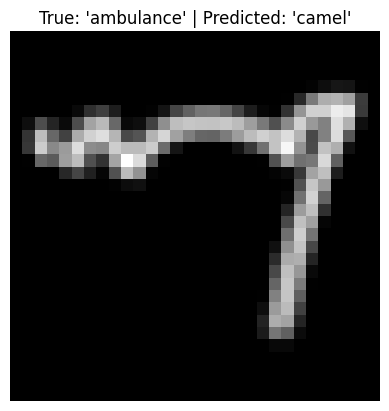

In [33]:
# Make sure your model is loaded and in eval mode

model.eval()

# Let's search for a misclassified image
mistake_found = False
for i, (img_tensor, label_index) in enumerate(val_ds):
    if i > 5000: break # Search first 5000 samples
        
    input_batch = img_tensor.unsqueeze(0).to(DEVICE)
    true_label_name = CLASSES[label_index]
    
    with torch.no_grad():
        output = model(input_batch)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_index = torch.max(probabilities, 1)
        predicted_label_name = CLASSES[predicted_index.item()]

    if predicted_label_name != true_label_name:
        print(f"FOUND A MISTAKE AT INDEX {i}")
        print(f"True Label was: '{true_label_name}'")
        print(f"Model Predicted: '{predicted_label_name}' with {confidence.item():.2%} confidence.")
        
        # Let's see the model's top 3 guesses
        top3_probs, top3_indices = torch.topk(probabilities, 3)
        print("\nModel's Top 3 Guesses:")
        for prob, idx in zip(top3_probs.flatten(), top3_indices.flatten()):
            print(f"- {CLASSES[idx.item()]:<15} ({prob.item():.2%})")

        plt.imshow(img_tensor.squeeze(), cmap='gray')
        plt.title(f"True: '{true_label_name}' | Predicted: '{predicted_label_name}'")
        plt.axis('off')
        plt.show()
        mistake_found = True
        break
        
if not mistake_found:
    print("Couldn't find any mistakes in the first 5000 samples. Your model is very good!")

In [34]:
from PIL import Image

# --- CONFIGURATION ---
MY_IMAGE_FILE = "my_drawing.png" #<-- CHANGE THIS TO YOUR FILENAME

# --- Load and Preprocess Your Image ---
try:
    my_image = Image.open(MY_IMAGE_FILE).convert("L") # Convert to grayscale
except FileNotFoundError:
    print(f"Error: Make sure the file '{MY_IMAGE_FILE}' is in your project folder!")
    # Stop here if file not found
    
if 'my_image' in locals():
    # The model was trained on white drawings on a black background. 
    # If you drew black on white, we need to invert the colors.
    # If you drew white on black, you can comment out the next line.
    my_image = Image.fromarray(255 - np.array(my_image))

    input_tensor = test_tf(my_image)
    input_batch = input_tensor.unsqueeze(0).to(DEVICE)

    # --- Make Prediction ---
    model.eval()
    with torch.no_grad():
        output = model(input_batch)
        probabilities = F.softmax(output, dim=1)
        
        top5_probs, top5_indices = torch.topk(probabilities, 5)
        
        print(f"--- Model's Prediction for '{MY_IMAGE_FILE}' ---")
        print("\nTop 5 Guesses:")
        for prob, idx in zip(top5_probs.flatten(), top5_indices.flatten()):
            print(f"- {CLASSES[idx.item()]:<15} ({prob.item():.2%})")

    # --- Visualize ---
    plt.imshow(my_image, cmap='gray')
    predicted_label = CLASSES[top5_indices[0][0].item()]
    plt.title(f"My drawing! Model's best guess: '{predicted_label}'")
    plt.axis('off')
    plt.show()

Error: Make sure the file 'my_drawing.png' is in your project folder!


In [35]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch.nn.functional as F

# Make sure your model is loaded and in eval mode
model.eval()

def show_prediction(sample_index):
    """
    This function takes a sample index, runs a prediction, and displays the result.
    It's designed to be called by the interactive widget.
    """
    # Clear the previous output to keep the display clean
    clear_output(wait=True)
    
    # --- Get Data and Preprocess ---
    img_tensor, label_index = master_dataset[sample_index]
    true_label_name = CLASSES[label_index]
    input_batch = img_tensor.unsqueeze(0).to(DEVICE)

    # --- Make Prediction ---
    with torch.no_grad():
        output = model(input_batch)
        probabilities = F.softmax(output, dim=1)
        
        # Get the top guess
        confidence, predicted_index = torch.max(probabilities, 1)
        predicted_label_name = CLASSES[predicted_index.item()]
        
        # Get the top 5 guesses for more insight
        top5_probs, top5_indices = torch.topk(probabilities, 5)

    # --- Display Results ---
    print(f"Showing Sample Index: {sample_index}")
    print("-" * 30)
    print(f"True Label:      '{true_label_name}'")
    print(f"Model Predicted: '{predicted_label_name}' with {confidence.item():.2%} confidence.")
    print("-" * 30)

    print("Model's Top 5 Guesses:")
    for prob, idx in zip(top5_probs.flatten(), top5_indices.flatten()):
        print(f"- {CLASSES[idx.item()]:<15} ({prob.item():.2%})")
        
    plt.figure(figsize=(5, 5))
    plt.imshow(img_tensor.squeeze(), cmap='gray')
    plt.title(f"True: '{true_label_name}' | Predicted: '{predicted_label_name}'")
    plt.axis('off')
    plt.show()


# --- Create and Display the Interactive Widget ---
# Note: We are using a subset of the master_dataset for the slider max value
# to prevent potential memory issues with a very large number in the widget.
# You can change max_index to len(master_dataset) - 1 if it runs smoothly.
max_index = 500000-1

slider = widgets.IntSlider(
    min=0,
    max=max_index,
    step=1,
    description='Sample Index:',
    value=0,
    continuous_update=False, # Only update when you release the slider
    layout=widgets.Layout(width='80%')
)

interactive_widget = widgets.interactive(show_prediction, sample_index=slider)
display(interactive_widget)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Sample Index:', layout=Layout(w…

In [36]:
# ==============================================================
# 🚀 Final Step: Launch the Web Server
# ==============================================================
# First, make sure Flask is installed

from flask import Flask, request, jsonify, send_from_directory
from PIL import Image
import base64
import io
import torch
import torch.nn.functional as F
import numpy as np

# Initialize the Flask app

app = Flask(__name__)

# This confirms your model is loaded and ready
model.to(DEVICE)
model.eval()
print("✅ Model is loaded and in evaluation mode.")

# --- API Routes ---

@app.route('/')
def serve_index():
    # This serves the index.html file from your project directory
    return send_from_directory('.', 'index.html')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    img_data = base64.b64decode(data['image'].split(',')[1])
    img = Image.open(io.BytesIO(img_data)).convert('L') # Open as grayscale

    # The model was trained on white-on-black, but our canvas is black-on-white.
    # So we invert the image colors.
    img = Image.fromarray(255 - np.array(img))

    # Preprocess the image
    input_tensor = test_tf(img)
    input_batch = input_tensor.unsqueeze(0).to(DEVICE)

    # Make prediction
    with torch.no_grad():
        output = model(input_batch)
        probabilities = F.softmax(output, dim=1)
        top5_probs, top5_indices = torch.topk(probabilities, 5)

    # Format the results
    predictions = []
    for prob, idx in zip(top5_probs.flatten(), top5_indices.flatten()):
        predictions.append({
            "class": CLASSES[idx.item()],
            "probability": f"{prob.item():.2%}"
        })

    return jsonify(predictions)


# --- Run the App ---
print("🚀 Starting Flask server...")
print("Open your browser and go to http://127.0.0.1:5002")

# Note: This will run forever until you stop the cell manually.
app.run(host='0.0.0.0', port=5002)

✅ Model is loaded and in evaluation mode.
🚀 Starting Flask server...
Open your browser and go to http://127.0.0.1:5002
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5002
 * Running on http://10.30.201.34:5002
Press CTRL+C to quit
127.0.0.1 - - [13/Oct/2025 12:37:39] "GET / HTTP/1.1" 304 -
10.30.201.34 - - [13/Oct/2025 12:38:03] "GET / HTTP/1.1" 304 -
10.30.201.34 - - [13/Oct/2025 12:38:11] "POST /predict HTTP/1.1" 200 -
10.30.201.34 - - [13/Oct/2025 12:38:32] "POST /predict HTTP/1.1" 200 -
10.30.201.34 - - [13/Oct/2025 12:40:23] "POST /predict HTTP/1.1" 200 -
